<h1 align="center">Traffic Managament System Model</h1>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

df_train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
print(df_train.info())
print(f"\nNull values : \n{df_train.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB
None

Null values : 
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather         

In [4]:
#null values in temperature filled with median temperature
df_train['Temperature'] = df_train['Temperature'].fillna(df_train['Temperature'].median())

#filling weather and roadtype with most common type of it
df_train['Weather'] = df_train['Weather'].fillna(df_train['Weather'].mode()[0])
df_train['RoadType'] = df_train['RoadType'].fillna(df_train['RoadType'].mode()[0])

In [5]:
time_split = df_train['timestamp'].str.split(':', expand=True)
df_train['hour'] = time_split[0].astype(int)
df_train['minute'] = time_split[1].astype(int)

In [15]:
#one hot encoding for categorical data such as roadtype , landmark etc 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform='pandas')

df_train_encoded = encoder.fit_transform(df_train[['Landmarks','Weather','RoadType','LargeVehicles']])
df_train_numeric = df_train[['day','demand','NumberofLanes','Temperature']]

df_train_new = pd.concat([df_train_encoded,df_train_numeric],axis=1)
df_train_new.head()

,Landmarks_No,Landmarks_Yes,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,RoadType_Highway,RoadType_Residential,RoadType_Street,LargeVehicles_Allowed,LargeVehicles_Not Allowed,day,demand,NumberofLanes,Temperature
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,48,0.048804,1,16.382587
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,48,0.118507,3,31.104565
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,48,0.027132,1,25.919267
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,48,0.003272,1,16.382587
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,48,0.010819,1,10.803667


<Axes: >

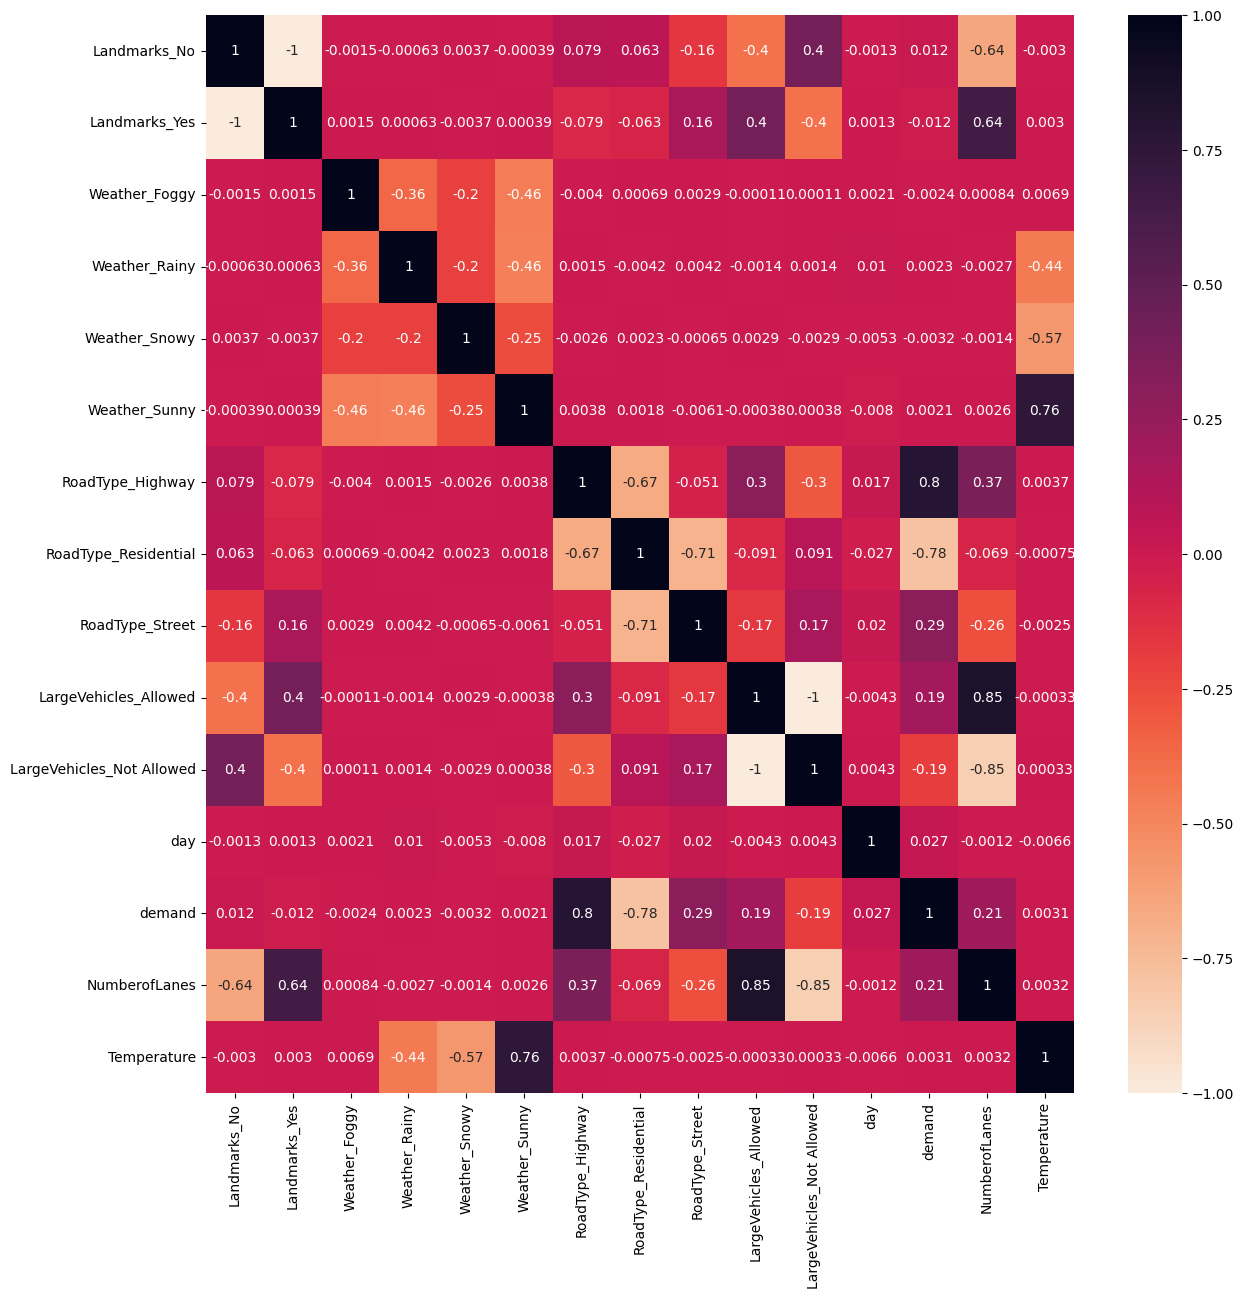

In [16]:
plt.figure(figsize=(14, 14))
corr = df_train_new.corr()
sns.heatmap(corr,annot=True,cmap="rocket_r")